# NB1 — Kernel SHAP: 6‑dim Block‑Space Explainer (v2)

### Core idea
Instead of operating in the 18,824-dimensional embedding space, problem is redused to **6 binary features**, one per model block. Each feature acts as an on/off switch:  
- 1: use the real embedding for the block
- 0: replace the block with a baseline

This reduces the complexity from an intractable space to exactly 2^6 = 64 feature combinations, enabling exact Shapley value computation with `KernelExplainer`. However in this setup, absent blocks are replaced with a fixed baseline, so this is **Mean Ablation in intent**. In contrast, standard implementation of Kernel SHAP estimates feature contributions by sampling multiple background instances rather than relying on a single baseline.

*(A more conventional SHAP application is presented in NB2, which uses `shap.PartitionExplainer` on the full 18824‑dim flat input with a hierarchical coalition structure.)*  

### Block Definition
Previous experiments showed that embedding blocks follow the same order as in the configuration file. Based on the initial configuration, the 6 blocks are defined as:

| Index | Block    | Side     | Raw dims   | Dim amount  |
|-------|----------|----------|------------|-------------|
| 0     | NT2      | Bacteria | 0:1536     | 1536 dims   |
| 1     | MegaDNA  | Bacteria | 1536:2500  | 964 dims    |
| 2     | DNABERT2 | Bacteria | 2500:4036  | 1536 dims   |
| 3     | NT2      | Phage    | 4036:5572  | 1536 dims   |
| 4     | MegaDNA  | Phage    | 5572:6536  | 964 dims    |
| 5     | DNABERT2 | Phage    | 6536:18824 | 12288 dims  |


### Baseline Definition
The baseline represents the absence of all real blocks for a given phage–bacterium pair and  stored as `BASELINE_MODE` parameter.

NB1 supports several baseline types:  
- `mean`: column-wise mean embedding computed over a background dataset
- `median`: column-wise median embedding
- `zero`: all-zero vector
- `pair N`: embedding of a specific dataset pair used as a biological reference. Allows evaluating contributions relative to a concrete biological example rather than a purely statistical average. Here `N` is the `pair_id` in the dataset, for example `pair 1127`

While the test dataset was used initially, using training data may be preferable. However, the same phage and bacteria entities appear in both sets, the difference may be negligible.

### Explanation Modes
**Variants:**

**6‑dim / global**: all 6 blocks vary - explains the full pair interaction.  
**frozen‑bacteria / free‑phage** (3‑dim): bacteria blocks are fixed to 1 (real), only phage blocks vary - measures phage contribution given the real bacterial context.  
**frozen‑phage / free‑bacteria** (3‑dim): symmetric to the previous variant.

NB1 supports both local and global explanations.
- **Local explanation:** Shapley values are computed for a single phage–bacterium pair. This explains how each block contributes to the prediction for that specific input. Computation is performed in a loops over the `TARGET_PAIRS` list, allowing selective and efficient evaluation. Works with all variants.

- **Global explanation:** Feature importance is aggregated across multiple pairs using the mean absolute Shapley value. The number of evaluated samples is controlled by `N_PAIRS_GLOBAL`, which can be either an integer (amount of randomly sampled pairs from the dataset) or `"all"` to use the entire dataset. Implemented only via 6-dim variant.


### Mask semantics: 
Feature perturbation is realized through masking.  
`mask[i] = 1` → use the real embedding for block `i`.  
`mask[i] = 0` → replace block `i` with the corresponding slice of the **baseline vector**.  

The reference input is defined as:  
`background = zeros(1, 6)` all blocks replaced with baseline

### Implementation note
The explainer operates only on the 6-dimensional mask and interacts with the model through the prediction object `BlockMaskPredictor`. `BlockMaskPredictor` unfolds the provided mask into full 18,824-dimensional embedding for the current pair before passing it through PCA and the classifier. It also handles local variable `_current_full`, which stores the current testing sample. This is not "by the book" solution, so **be careful when modifying the codebase** and **call `predictor.set_sample(x_full)` before each SHAP explaination call**. Otherwise, predictions will be computed using the previously set sample.

___
## Section 0 — Setup

The original location of this notebook is a subfolder of the project. However, for proper functioning it needs to be started from the **project root** so it can access all dependencies and imports. Therefore, the next cell (the very first section of the notebook containing `%cd ..`) may need to be run multiple times until you see the desired folder as output: `Current Working Directory: /data/your.user/pbi`.

*You might not need to run the first cell if this notebook is already in the project root folder.*

In [2]:
import os
import sys

# 1. Change the working directory to the project root
%cd ..

# 2. Add the root directory to the Python path so imports work
sys.path.append(os.getcwd())

# 3. Verify we are in the right place
print(f"Current Working Directory: {os.getcwd()}")
# !ls # Optional: list files to confirm you see 'main.py' and 'pbi_utils'p

/data/pavel.degterev/pbi
Current Working Directory: /data/pavel.degterev/pbi


In [6]:
import json
import shap
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tqdm.auto import tqdm
from pbi_utils.logging import Logging, INFO, DEBUG
from pbi_utils.data_manager import H5pyEmbeddingsManager #, PerphectDataInput, EmbeddingsManager
from pbi_utils.config_parser_XAI import parse_config
#from main import parse_config

___
## Section 1 — Configuration

Under normal use, experiments can be reconfigured by modifying only this cell, while the rest of the notebook remains unchanged. It contains main user-editable parameters for Nb1, unless the model configuration is changed, in which case Section 2 needs to be changed accordingly. 

In [7]:
CONFIG_PATH    = 'XAI/bundle/best_model_XAI.yaml' # "model_configs/best_model_XAI.yaml"
BASELINE_MODE  = "zero"   # "zero" | "median" | "mean" | "pair N" - for example example "pair 1127"
RANDOM_SEED    = 48

# Amount of pairs used for testing:
N_PAIRS_GLOBAL = 'all'      # "all" | int - how many pairs for global mean|SHAP| analysis

FILTERED_PAIRS = [
    {"id": 788,  "bacterium_id": 153,  "phage_id": 2014},
    {"id": 939,  "bacterium_id": 153,  "phage_id": 2153},
    {"id": 2271, "bacterium_id": 1869, "phage_id": 6187},
    {"id": 741,  "bacterium_id": 5859, "phage_id": 451},
    {"id": 728,  "bacterium_id": 5859, "phage_id": 5924},
    {"id": 768,  "bacterium_id": 5859, "phage_id": 5928},
]

NEGATIVE_PAIRS = [
    {"id": 4505,  "bacterium_id": 1869,  "phage_id": 4095},
    {"id": 7056,  "bacterium_id": 5196	,  "phage_id": 5303},
    {"id": 6430, "bacterium_id": 5201, "phage_id": 5322},
    {"id": 3605,  "bacterium_id": 5859, "phage_id": 2246},
] # non standard subset for specific tests 

TARGET_PAIRS = FILTERED_PAIRS[:]  # set to a subset to run fewer
# ───────────────────────────────────────────────────────────────────────────
print(f"Baseline mode: {BASELINE_MODE}")
print(f"Target pairs ({len(TARGET_PAIRS)}): {[p['id'] for p in TARGET_PAIRS]}")

Baseline mode: zero
Target pairs (6): [788, 939, 2271, 741, 728, 768]


In [8]:
tqdm.pandas()  # Initialize tqdm with pandas
Logging.set_logging_level(DEBUG)
# logger = Logging()

config = parse_config(CONFIG_PATH)
DEVICE = config.device
print(f"Device: {DEVICE}")

[INFO] Configuration loaded from XAI/bundle/best_model_XAI.yaml: Config(input_perphect=bacteria_df='data/perphect-data/public_data_set/bacteria_df.csv' phages_df='data/perphect-data/public_data_set/phages_df.csv' couples_df='data/perphect-data/public_data_set/couples_df.csv', embeddings_dir=data/embeddings_XAI, num_gpu=1, gpu_id=3, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='PCA' n_components_bacteria=500 n_components_phages=500), phages_embedding_models=[], compute_phages_embeddings=[], bacteria_embedding_models=[], compute_bacteria_embeddings=[], torch_num_threads=-1, output_dir=output/best_model_XAI/, classifier=BasicMLPClassifier({'mlp_params': [256, 128], 'dropout': 0.4}))
Device: cuda:3


In [9]:
# I guess that here should be custom embeddings folder to not mess up OG embeddings
CUSTOM_EMBEDDINGS_FOLDER = "XAI/embeddings"
output_manager = H5pyEmbeddingsManager(CUSTOM_EMBEDDINGS_FOLDER)
#output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from XAI/embeddings


___
## Section 2 — Block Definitions

Raw embedding layout:
- **Bacteria** (4036-dim): NT2 `[0:1536]`, MegaDNA `[1536:2500]`, DNABERT2 `[2500:4036]`
- **Phage** (14788-dim): NT2 `[0:1536]`, MegaDNA `[1536:2500]`, DNABERT2 `[2500:14788]`

In the concatenated 18824-dim vector phage indices are offset by 4036.

In [10]:
BACT_DIM = 4036
PHAG_DIM = 14788
FULL_DIM = BACT_DIM + PHAG_DIM  # 18824

# Blocks in the FULL 18824-dim concatenated space [start, end)
BACT_BLOCKS = {
    "bact_NT2":     (0,    1536),
    "bact_MegaDNA": (1536, 2500),
    "bact_DNABERT2": (2500, 4036),
}

PHAG_BLOCKS = {
    "phag_NT2":     (4036, 5572),
    "phag_MegaDNA": (5572, 6536),
    "phag_DNABERT2": (6536, 18824),
}

# Combined ordered dict: order matters — must match 6-dim mask index
BLOCKS = {
    **BACT_BLOCKS,
    **PHAG_BLOCKS,
}

BLOCK_NAMES  = list(BLOCKS.keys())   # 6 names in canonical order
N_BLOCKS     = len(BLOCK_NAMES)      # 6
BACT_BLOCK_NAMES = list(BACT_BLOCKS.keys())
PHAG_BLOCK_NAMES = list(PHAG_BLOCKS.keys())

print("Blocks (name → [start, end)):")
for i, (name, (s, e)) in enumerate(BLOCKS.items()):
    print(f"  [{i}] {name}: [{s}, {e})  width={e-s}")

Blocks (name → [start, end)):
  [0] bact_NT2: [0, 1536)  width=1536
  [1] bact_MegaDNA: [1536, 2500)  width=964
  [2] bact_DNABERT2: [2500, 4036)  width=1536
  [3] phag_NT2: [4036, 5572)  width=1536
  [4] phag_MegaDNA: [5572, 6536)  width=964
  [5] phag_DNABERT2: [6536, 18824)  width=12288


___
## Section 3 — Data & Model Loading (automated)

Data loading is expected in the `.pt` format and file location based on a modified version of the `config` class.

Under the `def __init__(self, yaml_config: YAMLConfig, raw_dict):`  
```python
# new instances
self.model_path = os.path.join(self.output_dir, "trained_model.pth")
self.bacteria_pca_path = os.path.join(self.output_dir, "pca_bacteria.pkl")
self.phage_pca_path = os.path.join(self.output_dir, "pca_phage.pkl")
self.test_path = os.path.join(self.output_dir, "test_dataset.pt")
```

Those were also integrated into the main script for automatic saving of:
- PCA components upon creation, via `pickle.dump(pca_bact, open(config.bacteria_pca_path, 'wb'))`
- The test dataset upon splitting, via `torch.save(test, config.test_path)`
- *The model name was also hardcoded in the main script for simplicity*

It may be useful to add a manual path option to the notebook’s configuration section and make it compatible with standard CSV files as well.

---

## Important standalone configuration note

The final modifications made before forking were aimed at enabling standalone execution and reducing dependencies on the original project structure. As a result, `config_parser_XAI` is currently configured to load all required resources directly from the XAI package directory.

The path definitions introduced above were therefore modified to point to bundled resources. For example:

```python
self.model_path = os.path.join("XAI/bundle/trained_model.pth")
```

and similarly for the PCA components and test dataset.

The standalone configuration is currently implemented in config_parser_XAI, allowing the XAI module to operate independently of the main project structure. When running the training `main.py` pipeline or new tests on new models, the original config_parser should be updated to include the changes described earlier in this section. These modifications can be copied directly from the corresponding implementation in config_parser_XAI, which serves as the standalone-compatible reference version.

In [11]:
# ── Load embedding test dataset ────────────────────────────────────────────
emb_test_data = torch.load(config.test_path, map_location=DEVICE)
emb_test_data = emb_test_data.reset_index(drop=True)

print('=== test initially designed to verify if right (filtered) df is used ===')
# Might be inappropriate for future cases 
print(f"emb_test_data: {len(emb_test_data)} rows, expected value 1426 after cleaning")
print(f"emb_test_data: {len(emb_test_data['phage_embedding'].iloc[0])} embedding lenght for bacteria, expected value 14788 before pca")
# This one is universally relevant
print(f"\nDistribution for {emb_test_data['interaction_type'].value_counts()}")

=== test initially designed to verify if right (filtered) df is used ===
emb_test_data: 1426 rows, expected value 1426 after cleaning
emb_test_data: 14788 embedding lenght for bacteria, expected value 14788 before pca

Distribution for interaction_type
0    1051
1     375
Name: count, dtype: int64


In [12]:
emb_test_data.head() # embeddings from the test part in the training stage

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,1127,2318,1869,1,"[tensor(-0.2436, device='cuda:3'), tensor(0.46...","[tensor(-0.4400, device='cuda:3'), tensor(0.56..."
1,4505,4095,1869,0,"[tensor(-0.2436, device='cuda:3'), tensor(0.46...","[tensor(0.3543, device='cuda:3'), tensor(-0.05..."
2,7056,5303,5196,0,"[tensor(-0.0618, device='cuda:3'), tensor(0.18...","[tensor(-0.0118, device='cuda:3'), tensor(0.18..."
3,6430,5322,5201,0,"[tensor(-0.1654, device='cuda:3'), tensor(0.29...","[tensor(-0.1430, device='cuda:3'), tensor(0.33..."
4,3605,2246,5859,0,"[tensor(-0.1581, device='cuda:3'), tensor(0.44...","[tensor(-0.1737, device='cuda:3'), tensor(0.38..."


In [10]:
# ── Load PCA objects ───────────────────────────────────────────────────────
with open(config.bacteria_pca_path, 'rb') as f:
    pca_bact = pickle.load(f)

with open(config.phage_pca_path, 'rb') as f:
    pca_phag = pickle.load(f)

print(f"pca_bact: {pca_bact.n_components_} components, input dim {pca_bact.n_features_in_}")
print(f"pca_phag: {pca_phag.n_components_} components, input dim {pca_phag.n_features_in_}")

pca_bact: 500 components, input dim 4036
pca_phag: 500 components, input dim 14788


In [11]:
# ── Load MLP model ─────────────────────────────────────────────────────────
bacterium_embed_size = 500 #len(emb_test_data["bacterium_embedding"].iloc[0])
phage_embed_size = 500 #len(emb_test_data["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(config.model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print(f"Model loaded → {DEVICE}, eval mode.")
print(model)
print()

Model loaded → cuda:3, eval mode.
MLPClassifier(mlp_params: [256, 128], dropout=0.4)



/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


___
## Section 4 — Baseline & Dataset Construction

The baseline vector is the "all blocks absent" reference. We compute it over the
unique bacteria and phage in the test set. Controlled by `BASELINE_MODE`.

In [12]:
def tensor_to_numpy(t):
    """Convert a PyTorch tensor or numpy array to a float64 numpy array."""
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy().astype(np.float64)
    return np.asarray(t, dtype=np.float64)


def build_baseline(emb_test_data, mode, seed=48):
    """
    Build a 18824-dim baseline embedding vector.

    Parameters
    ----------
    emb_test_data : pd.DataFrame
        Must have columns:
        id, bacterium_id, phage_id, bacterium_embedding, phage_embedding.
    mode : str
        'mean' | 'median' | 'zero' | 'pair N'
        Example: 'pair 1127'
    seed : int
        RNG seed (only for 'random_sample', that was removed in later versions).

    Returns
    -------
    np.ndarray of shape (18824,)
    """
    mode = str(mode).strip()

    unique_bact = emb_test_data.drop_duplicates(subset="bacterium_id")
    unique_phag = emb_test_data.drop_duplicates(subset="phage_id")

    bact_stack = np.stack([tensor_to_numpy(t) for t in unique_bact["bacterium_embedding"]])
    phag_stack = np.stack([tensor_to_numpy(t) for t in unique_phag["phage_embedding"]])

    if mode == "mean":
        b = bact_stack.mean(axis=0)
        p = phag_stack.mean(axis=0)

    elif mode == "median":
        b = np.median(bact_stack, axis=0)
        p = np.median(phag_stack, axis=0)

    elif mode == "zero":
        b = np.zeros(bact_stack.shape[1], dtype=np.float64)
        p = np.zeros(phag_stack.shape[1], dtype=np.float64)

    elif mode.lower().startswith("pair"):
        parts = mode.split()

        if len(parts) != 2:
            raise ValueError(
                f"Invalid pair baseline format: {mode!r}. "
                "Use format: 'pair 1127'"
            )

        try:
            pair_id = int(parts[1])
        except ValueError:
            raise ValueError(
                f"Invalid pair baseline format: {mode!r}. "
                "Pair id must be an integer, e.g. 'pair 1127'."
            )

        rows = emb_test_data.loc[emb_test_data["id"] == pair_id]
        if len(rows) == 0:
            raise ValueError(
                f"Pair baseline requested for id={pair_id}, "
                "but this id was not found in emb_test_data."
            )
        if len(rows) > 1:
            raise ValueError(
                f"Pair baseline requested for id={pair_id}, "
                f"but found {len(rows)} rows. Expected exactly 1 row."
            )

        row = rows.iloc[0]
        b = tensor_to_numpy(row["bacterium_embedding"])
        p = tensor_to_numpy(row["phage_embedding"])

    else:
        raise ValueError(
            f"Unknown baseline mode: {mode!r}. "
            "Use 'mean', 'median', 'zero', or 'pair N'."
        )

    return np.concatenate([b, p]).astype(np.float64)

In [13]:
# ── Baseline creation ───────────────────────────────────────────────────────
baseline_full = build_baseline(emb_test_data, BASELINE_MODE, RANDOM_SEED)

assert baseline_full.shape == (FULL_DIM,), f"Expected ({FULL_DIM},), got {baseline_full.shape}"
print(f"Baseline built — mode={BASELINE_MODE!r}, shape={baseline_full.shape}")

Baseline built — mode='zero', shape=(18824,)


In [14]:
# ── X_raw creation + Sanity Check ────────────────────────────────────────────
# X_raw: (N, 18824) concatenated raw embeddings (aligned to emb_test_data)

bact_arrs = np.stack([tensor_to_numpy(t) for t in emb_test_data["bacterium_embedding"]])
phag_arrs = np.stack([tensor_to_numpy(t) for t in emb_test_data["phage_embedding"]])
X_raw = np.concatenate([bact_arrs, phag_arrs], axis=1)

assert X_raw.shape[1] == FULL_DIM, f"Expected {FULL_DIM} cols, got {X_raw.shape[1]}"
print(f"X_raw shape: {X_raw.shape}")

X_raw shape: (1426, 18824)


___
## Section 5 — BlockMaskPredictor Class

Call `predictor.set_sample(x_full)` before each SHAP explain call.

In [15]:
class BlockMaskPredictor:
    """
    Wraps the PBI pipeline for KernelExplainer.

    KernelExplainer works in a 6-dim binary space: each feature = one model block.
    1 = use real embedding for that block, 0 = replace with baseline.
    The predictor reconstructs the full 18824-dim vector from this mask.

    Note on taxonomy: because absent blocks are replaced with a FIXED baseline
    (mean/median of training distribution), this is equivalent to Mean Ablation
    in intent. Standard KernelSHAP would use random samples from the marginal
    distribution for absent features — here we cannot do that because the feature
    space is the block structure itself, not individual dimensions.
    """

    def __init__(
        self,
        baseline_full: np.ndarray,
        blocks: dict,
        block_names: list,
        pca_bact,
        pca_phag,
        model,
        device,
        bact_dim: int,
    ):
        self.baseline    = baseline_full.copy()
        self.blocks      = blocks
        self.block_names = block_names
        self.pca_bact    = pca_bact
        self.pca_phag    = pca_phag
        self.model       = model
        self.device      = device
        self.bact_dim    = bact_dim
        self._current_full: np.ndarray | None = None

    def set_sample(self, x_full: np.ndarray):
        """Set the real 18824-dim embedding for the current sample."""
        if x_full.shape != (FULL_DIM,):
            raise ValueError(f"Expected shape ({FULL_DIM},), got {x_full.shape}")
        self._current_full = x_full.astype(np.float64)

    def expand_mask(self, x_6d: np.ndarray) -> np.ndarray:
        """
        (6,) mask → (18824,) mixed embedding via linear interpolation.
        mask[i]=1 → real block; mask[i]=0 → baseline block.
        """
        if self._current_full is None:
            raise RuntimeError("Call set_sample() before using the predictor.")
        out = self.baseline.copy()
        for i, name in enumerate(self.block_names):
            s, e = self.blocks[name]
            alpha = float(x_6d[i])
            out[s:e] = alpha * self._current_full[s:e] + (1.0 - alpha) * self.baseline[s:e]
        return out

    def __call__(self, x_6d_batch: np.ndarray) -> np.ndarray:
        """
        Callable for KernelExplainer.
        Input  : (batch_size, 6)  float array (mask values in [0, 1])
        Output : (batch_size,)    float array (interaction probability)
        """
        full_batch = np.stack(
            [self.expand_mask(x_6d_batch[i]) for i in range(len(x_6d_batch))]
        )  # (batch, 18824)

        bact_pca = self.pca_bact.transform(
            full_batch[:, : self.bact_dim].astype(np.float64)
        )  # (batch, 500)
        phag_pca = self.pca_phag.transform(
            full_batch[:, self.bact_dim :].astype(np.float64)
        )  # (batch, 500)

        bact_t = torch.from_numpy(bact_pca.astype(np.float32)).to(self.device)
        phag_t = torch.from_numpy(phag_pca.astype(np.float32)).to(self.device)

        with torch.no_grad():
            logits = self.model(bact_t, phag_t)
            probs  = torch.softmax(logits, dim=1)[:, 1]

        return probs.cpu().numpy()

    def make_frozen_predictor(self, frozen_side: str):
        """
        Returns a 3-dim predictor with one organism frozen at its real embedding.

        Parameters
        ----------
        frozen_side : str
            'bacteria' → bacteria fixed at 1, explain phage 3 blocks (indices 3,4,5).
            'phage'    → phage fixed at 1, explain bacteria 3 blocks (indices 0,1,2).

        Returns
        -------
        predict_3d : callable
            (batch, 3) → (batch,)
        names_3d : list[str]
            Block names corresponding to the 3 free dimensions.
        """
        predictor = self  # closure captures self

        if frozen_side == 'bacteria':
            # bacteria blocks (0,1,2) = 1; phage blocks (3,4,5) are free
            def predict_3d(x_3d_batch: np.ndarray) -> np.ndarray:
                n = x_3d_batch.shape[0]
                x_6d = np.ones((n, 6), dtype=np.float64)
                x_6d[:, 3:6] = x_3d_batch
                return predictor(x_6d)
            return predict_3d, ['phag_NT2', 'phag_MegaDNA', 'phag_DNABERT2']

        elif frozen_side == 'phage':
            # phage blocks (3,4,5) = 1; bacteria blocks (0,1,2) are free
            def predict_3d(x_3d_batch: np.ndarray) -> np.ndarray:
                n = x_3d_batch.shape[0]
                x_6d = np.ones((n, 6), dtype=np.float64)
                x_6d[:, 0:3] = x_3d_batch
                return predictor(x_6d)
            return predict_3d, ['bact_NT2', 'bact_MegaDNA', 'bact_DNABERT2']

        else:
            raise ValueError("frozen_side must be 'bacteria' or 'phage'")

In [16]:
predictor = BlockMaskPredictor(
    baseline_full = baseline_full,
    blocks        = BLOCKS,
    block_names   = BLOCK_NAMES,
    pca_bact      = pca_bact,
    pca_phag      = pca_phag,
    model         = model,
    device        = DEVICE,
    bact_dim      = BACT_DIM,
)
print("BlockMaskPredictor created.")

BlockMaskPredictor created.


In [17]:
# Sanity check: all-ones mask should recover the real embedding and match direct model forward pass
print("Sanity checks — all-ones mask == real embedding → should match direct inference:")
for pair in TARGET_PAIRS[:2]:
    row = emb_test_data.loc[emb_test_data["id"] == pair["id"]].iloc[0]
    idx = emb_test_data.index.get_loc(row.name)
    x_full = X_raw[idx]
    predictor.set_sample(x_full)

    prob_mask = predictor(np.ones((1, N_BLOCKS), dtype=np.float64))[0]

    # Direct forward pass
    bact_pca = pca_bact.transform(x_full[:BACT_DIM].reshape(1, -1))
    phag_pca = pca_phag.transform(x_full[BACT_DIM:].reshape(1, -1))
    with torch.no_grad():
        logits_direct = model(
            torch.from_numpy(bact_pca.astype(np.float32)).to(DEVICE),
            torch.from_numpy(phag_pca.astype(np.float32)).to(DEVICE),
        )
        prob_direct = torch.softmax(logits_direct, dim=1)[0, 1].item()

    diff = abs(prob_mask - prob_direct)
    status = "OK" if diff < 1e-5 else "MISMATCH"
    print(f"  pair {pair['id']}: mask={prob_mask:.6f}  direct={prob_direct:.6f}  diff={diff:.2e}  [{status}]")

Sanity checks — all-ones mask == real embedding → should match direct inference:
  pair 788: mask=0.999701  direct=0.999701  diff=0.00e+00  [OK]
  pair 939: mask=0.999835  direct=0.999835  diff=0.00e+00  [OK]


___
## Section 6 — KernelExplainer Setup

Background = `zeros(1, 6)` encodes "all blocks set to baseline" as the SHAP reference.  
The explainer is created **once** and reused across all pairs (only `predictor.set_sample()` changes).

In [18]:
# Background: single row of zeros = "all blocks replaced by baseline"
background_6d = np.zeros((1, N_BLOCKS), dtype=np.float64)

explainer = shap.KernelExplainer(predictor, background_6d)

print(f"KernelExplainer created.")
print(f"  background shape : {background_6d.shape}")
print(f"  feature names    : {BLOCK_NAMES}")
print(f"  expected_value will be set after first explain call")

KernelExplainer created.
  background shape : (1, 6)
  feature names    : ['bact_NT2', 'bact_MegaDNA', 'bact_DNABERT2', 'phag_NT2', 'phag_MegaDNA', 'phag_DNABERT2']
  expected_value will be set after first explain call


___
## Section 7 — Local explanation
**Calculating Model importance for individual pairs**  
`run_kernel_shap_for_pairs()` - Main automation function: loops over pairs set in configuration, runs KernelExplainer, collects structured results.

In [19]:
def run_kernel_shap_for_pairs(
    pair_list,
    predictor,
    explainer,
    emb_test_data,
    X_raw,
    block_names,
    n_blocks,
    baseline_mode,
    nsamples="auto",
    verbose=True,
):
    """
    Runs KernelExplainer for each pair in pair_list (6-dim global mode).

    Parameters
    ----------
    pair_list : list[dict]
        Each dict must have 'id', 'bacterium_id', 'phage_id'.
    predictor : BlockMaskPredictor
    explainer : shap.KernelExplainer
    emb_test_data : pd.DataFrame
    X_raw : np.ndarray  shape (N, 18824)
    block_names : list[str]
    n_blocks : int
    baseline_mode : str
    nsamples : int | str  SHAP samples per call (default 'auto')
    verbose : bool

    Returns
    -------
    df : pd.DataFrame  (one row per pair, columns = block_names + metadata)
    json_results : list[dict]  (JSON-serializable, suitable for AI analysis)
    """
    records      = []
    json_results = []

    for i, pair in enumerate(pair_list):
        if verbose:
            print(f"[{i+1}/{len(pair_list)}] pair_id={pair['id']} "
                  f"(bact={pair['bacterium_id']}, phag={pair['phage_id']})")

        rows = emb_test_data.loc[emb_test_data["id"] == pair["id"]]
        if len(rows) == 0:
            print(f"  WARNING: pair_id {pair['id']} not found in emb_test_data — skipping.")
            continue
        row = rows.iloc[0]
        idx = emb_test_data.index.get_loc(row.name)
        x_full = X_raw[idx]
        predictor.set_sample(x_full)

        # Full prediction with real embeddings (all-ones mask)
        x_ones = np.ones((1, n_blocks), dtype=np.float64)
        pred_prob = float(predictor(x_ones)[0])

        # KernelSHAP in the 6-dim mask space
        sv = explainer.shap_values(x_ones, nsamples=nsamples, silent=True)
        # sv shape: (1, n_blocks)
        shap_vals = {name: float(sv[0, j]) for j, name in enumerate(block_names)}
        base_val  = float(explainer.expected_value)

        if verbose:
            approx = base_val + sum(shap_vals.values())
            print(f"  pred={pred_prob:.4f}  base={base_val:.4f}  "
                  f"shap_sum={sum(shap_vals.values()):.4f}  "
                  f"approx={approx:.4f}  err={abs(approx - pred_prob):.4f}")

        record = {
            "pair_id":       pair["id"],
            "bacterium_id":  pair["bacterium_id"],
            "phage_id":      pair["phage_id"],
            "true_label":    int(row["interaction_type"]),
            "pred_prob":     pred_prob,
            **shap_vals,
        }
        records.append(record)

        json_results.append({
            "pair_id":        pair["id"],
            "bacterium_id":   pair["bacterium_id"],
            "phage_id":       pair["phage_id"],
            "baseline_mode":  baseline_mode,
            "true_label":     int(row["interaction_type"]),
            "pred_prob":      pred_prob,
            "expected_value": base_val,
            "shap_sum":       sum(shap_vals.values()),
            "shap_values":    shap_vals,
        })

    df = pd.DataFrame(records)
    return df, json_results

print("run_kernel_shap_for_pairs() defined.")

run_kernel_shap_for_pairs() defined.


In [20]:
# Run for TARGET_PAIRS
df_target, json_results = run_kernel_shap_for_pairs(
    pair_list     = TARGET_PAIRS,
    predictor     = predictor,
    explainer     = explainer,
    emb_test_data = emb_test_data,
    X_raw         = X_raw,
    block_names   = BLOCK_NAMES,
    n_blocks      = N_BLOCKS,
    baseline_mode = BASELINE_MODE,
    nsamples      = "auto",
    verbose       = True,
)

print(f"\nResults for {len(df_target)} target pairs:")
display(df_target)

[1/6] pair_id=788 (bact=153, phag=2014)
  pred=0.9997  base=0.0000  shap_sum=0.9997  approx=0.9997  err=0.0000
[2/6] pair_id=939 (bact=153, phag=2153)
  pred=0.9998  base=0.0000  shap_sum=0.9998  approx=0.9998  err=0.0000
[3/6] pair_id=2271 (bact=1869, phag=6187)
  pred=1.0000  base=0.0000  shap_sum=1.0000  approx=1.0000  err=0.0000
[4/6] pair_id=741 (bact=5859, phag=451)
  pred=1.0000  base=0.0000  shap_sum=1.0000  approx=1.0000  err=0.0000
[5/6] pair_id=728 (bact=5859, phag=5924)
  pred=1.0000  base=0.0000  shap_sum=1.0000  approx=1.0000  err=0.0000
[6/6] pair_id=768 (bact=5859, phag=5928)
  pred=0.9998  base=0.0000  shap_sum=0.9998  approx=0.9998  err=0.0000

Results for 6 target pairs:


,pair_id,bacterium_id,phage_id,true_label,pred_prob,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2
0,788,153,2014,1,0.999701,0.252487,0.235022,0.011610,0.249741,0.252013,-0.001173
1,939,153,2153,1,0.999835,0.253538,0.237664,0.005692,0.251823,0.253076,-0.001958
2,2271,1869,6187,1,0.999992,0.283251,0.123150,0.047092,0.281020,0.283251,-0.017773
3,741,5859,451,1,0.999999,0.324651,0.059450,0.286105,0.324651,0.046329,-0.041188
4,728,5859,5924,1,0.999994,0.303746,0.098705,0.254929,0.303746,0.093530,-0.054663
5,768,5859,5928,1,0.999776,0.259656,0.239229,0.250698,0.259656,0.005671,-0.015135


___
## Section 8 — Global explanation 
**Calulating globally important models for given dataset**  
Global Mean |SHAP| over given dataset or optionally with over N_PAIRS_GLOBAL Rows

In [20]:
def run_global_mean_shap(
    emb_test_data,
    X_raw,
    predictor,
    explainer,
    block_names,
    n_blocks,
    baseline_mode,
    n_pairs,
    seed=42,
):
    """
    Sample n_pairs rows from emb_test_data and compute mean |SHAP| per block.

    Parameters
    ----------
    n_pairs : int | str
        Number of pairs to sample, or "all" to use the full dataset.

    Returns
    -------
    df_global     : pd.DataFrame
        Per-pair SHAP values.
    mean_abs_shap : pd.Series
        Mean |SHAP| per block (sorted descending).
    """
    if isinstance(n_pairs, str):
        if n_pairs.lower() != "all":
            raise ValueError("n_pairs must be an int or the string 'all'.")
        if len(emb_test_data) != len(X_raw):
            raise ValueError(
                f"Length mismatch: len(emb_test_data)={len(emb_test_data)} "
                f"!= len(X_raw)={len(X_raw)}"
            )
        n = len(emb_test_data)
        sampled_rows = emb_test_data.reset_index(drop=True)
    else:
        rng = np.random.default_rng(seed)
        n = min(n_pairs, len(emb_test_data))
        sampled_idx = rng.choice(len(emb_test_data), size=n, replace=False)
        sampled_rows = emb_test_data.iloc[sampled_idx].reset_index(drop=True)

    pair_list = [
        {
            "id": int(r["id"]),
            "bacterium_id": int(r["bacterium_id"]),
            "phage_id": int(r["phage_id"]),
        }
        for _, r in sampled_rows.iterrows()
    ]

    df_global, _ = run_kernel_shap_for_pairs(
        pair_list=pair_list,
        predictor=predictor,
        explainer=explainer,
        emb_test_data=emb_test_data,
        X_raw=X_raw,
        block_names=block_names,
        n_blocks=n_blocks,
        baseline_mode=baseline_mode,
        nsamples="auto",
        verbose=False,
    )

    mean_abs_shap = (
        df_global[block_names]
        .abs()
        .mean()
        #.sort_values(ascending=False)
    )
    return df_global, mean_abs_shap

In [21]:
print(f"Computing global {BASELINE_MODE} |SHAP| over {N_PAIRS_GLOBAL} pairs...")
df_global, mean_abs_shap = run_global_mean_shap(
    emb_test_data = emb_test_data,
    X_raw         = X_raw,
    predictor     = predictor,
    explainer     = explainer,
    block_names   = BLOCK_NAMES,
    n_blocks      = N_BLOCKS,
    baseline_mode = BASELINE_MODE,
    n_pairs       = N_PAIRS_GLOBAL,
    seed          = RANDOM_SEED,
)

print(f"\nGlobal {BASELINE_MODE} |SHAP| per block:")
print(mean_abs_shap.to_string())
# 6:45 on median and all 1.4k pairs

Computing global zero |SHAP| over all pairs...

Global zero |SHAP| per block:
bact_NT2         0.078082
bact_MegaDNA     0.044999
bact_DNABERT2    0.057547
phag_NT2         0.074310
phag_MegaDNA     0.052274
phag_DNABERT2    0.022386


### Local data saving and retrieval section

In [ ]:
os.makedirs("XAI/results/data", exist_ok=True)

# ── 1. Full global dump as its own file ─────────────────────────────────────
out_global_csv = f"XAI/results/data/nb1_{BASELINE_MODE}_global_on_{N_PAIRS_GLOBAL}_pairs.csv"
df_global.to_csv(out_global_csv, index=False)
print(f"Saved global dump CSV → {out_global_csv}")

Saved global dump CSV → XAI/results/data/nb1_zero_global_on_all_pairs.csv


In [ ]:
out_global_csv = f"XAI/results/data/nb1_{BASELINE_MODE}_global_on_{N_PAIRS_GLOBAL}_pairs.csv"
df_global = pd.read_csv(out_global_csv)

In [21]:
df_global.head()

,pair_id,bacterium_id,phage_id,true_label,pred_prob,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2
0,1127,1869,2318,1,9.988437e-01,0.200167,0.199391,0.199443,0.200089,0.200167,-0.000412
1,4505,1869,4095,0,4.646981e-13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,7056,5196,5303,0,4.397029e-10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,6430,5201,5322,0,7.549225e-10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,3605,5859,2246,0,2.378834e-07,0.000523,0.000484,0.000523,0.000523,-0.000997,-0.001057


In [22]:
len(df_global)

1426

___
## Section 9 — Frozen-Side Analysis

For each pair in `TARGET_PAIRS`, run:
1. **Frozen bacteria** (explain phage 3 blocks)
2. **Frozen phage** (explain bacteria 3 blocks)

In [23]:
def run_frozen_side_for_pairs(
    pair_list,
    predictor,
    emb_test_data,
    X_raw,
    frozen_side,
    baseline_mode,
    nsamples="auto",
    verbose=True,
):
    """
    Run 3-dim frozen KernelSHAP for a given frozen_side across pair_list.

    Parameters
    ----------
    frozen_side : str  'bacteria' or 'phage'

    Returns
    -------
    df : pd.DataFrame
    json_results : list[dict]
    """
    predict_3d, names_3d = predictor.make_frozen_predictor(frozen_side)
    n_free = len(names_3d)
    background_3d = np.zeros((1, n_free), dtype=np.float64)
    explainer_3d  = shap.KernelExplainer(predict_3d, background_3d)

    records      = []
    json_results = []

    for i, pair in enumerate(pair_list):
        if verbose:
            print(f"[{i+1}/{len(pair_list)}] frozen_side={frozen_side!r} "
                  f"pair_id={pair['id']}")

        rows = emb_test_data.loc[emb_test_data["id"] == pair["id"]]
        if len(rows) == 0:
            print(f"  WARNING: pair_id {pair['id']} not found — skipping.")
            continue
        row = rows.iloc[0]
        idx = emb_test_data.index.get_loc(row.name)
        x_full = X_raw[idx]
        predictor.set_sample(x_full)

        x_ones_3d = np.ones((1, n_free), dtype=np.float64)
        pred_prob  = float(predict_3d(x_ones_3d)[0])

        sv        = explainer_3d.shap_values(x_ones_3d, nsamples=nsamples, silent=True)
        shap_vals = {name: float(sv[0, j]) for j, name in enumerate(names_3d)}
        base_val  = float(explainer_3d.expected_value)

        if verbose:
            approx = base_val + sum(shap_vals.values())
            print(f"  pred={pred_prob:.4f}  base={base_val:.4f}  "
                  f"shap_sum={sum(shap_vals.values()):.4f}  "
                  f"approx={approx:.4f}  err={abs(approx - pred_prob):.4f}")

        record = {
            "pair_id":      pair["id"],
            "bacterium_id": pair["bacterium_id"],
            "phage_id":     pair["phage_id"],
            "frozen_side":  frozen_side,
            "true_label":   int(row["interaction_type"]),
            "pred_prob":    pred_prob,
            **shap_vals,
        }
        records.append(record)

        json_results.append({
            "pair_id":        pair["id"],
            "bacterium_id":   pair["bacterium_id"],
            "phage_id":       pair["phage_id"],
            "frozen_side":    frozen_side,
            "baseline_mode":  baseline_mode,
            "true_label":     int(row["interaction_type"]),
            "pred_prob":      pred_prob,
            "expected_value": base_val,
            "shap_sum":       sum(shap_vals.values()),
            "shap_values":    shap_vals,
        })

    return pd.DataFrame(records), json_results

print("run_frozen_side_for_pairs() defined.")

run_frozen_side_for_pairs() defined.


In [24]:
print("=== Frozen bacteria (explain phage) ===")
df_frozen_bact, json_frozen_bact = run_frozen_side_for_pairs(
    pair_list     = TARGET_PAIRS,
    predictor     = predictor,
    emb_test_data = emb_test_data,
    X_raw         = X_raw,
    frozen_side   = "bacteria",
    baseline_mode = BASELINE_MODE,
    nsamples      = "auto",
    verbose       = True,
)

print("\n=== Frozen phage (explain bacteria) ===")
df_frozen_phag, json_frozen_phag = run_frozen_side_for_pairs(
    pair_list     = TARGET_PAIRS,
    predictor     = predictor,
    emb_test_data = emb_test_data,
    X_raw         = X_raw,
    frozen_side   = "phage",
    baseline_mode = BASELINE_MODE,
    nsamples      = "auto",
    verbose       = True,
)

print("\nFrozen-bacteria results (phage SHAP):")
display(df_frozen_bact)
print("\nFrozen-phage results (bacteria SHAP):")
display(df_frozen_phag)

=== Frozen bacteria (explain phage) ===
[1/6] frozen_side='bacteria' pair_id=788
  pred=0.9997  base=0.0000  shap_sum=0.9997  approx=0.9997  err=0.0000
[2/6] frozen_side='bacteria' pair_id=939
  pred=0.9998  base=0.0000  shap_sum=0.9998  approx=0.9998  err=0.0000
[3/6] frozen_side='bacteria' pair_id=2271
  pred=1.0000  base=0.0000  shap_sum=1.0000  approx=1.0000  err=0.0000
[4/6] frozen_side='bacteria' pair_id=741
  pred=1.0000  base=0.0000  shap_sum=1.0000  approx=1.0000  err=0.0000
[5/6] frozen_side='bacteria' pair_id=728
  pred=1.0000  base=0.0000  shap_sum=1.0000  approx=1.0000  err=0.0000
[6/6] frozen_side='bacteria' pair_id=768
  pred=0.9998  base=0.0000  shap_sum=0.9998  approx=0.9998  err=0.0000

=== Frozen phage (explain bacteria) ===
[1/6] frozen_side='phage' pair_id=788
  pred=0.9997  base=0.0000  shap_sum=0.9997  approx=0.9997  err=0.0000
[2/6] frozen_side='phage' pair_id=939
  pred=0.9998  base=0.0000  shap_sum=0.9998  approx=0.9998  err=0.0000
[3/6] frozen_side='phage' pa

,pair_id,bacterium_id,phage_id,frozen_side,true_label,pred_prob,phag_NT2,phag_MegaDNA,phag_DNABERT2
0,788,153,2014,bacteria,1,0.999701,0.494195,0.501151,0.004354
1,939,153,2153,bacteria,1,0.999835,0.496522,0.500416,0.002897
2,2271,1869,6187,bacteria,1,0.999992,0.492923,0.513950,-0.006882
3,741,5859,451,bacteria,1,0.999999,0.998033,0.002784,-0.000818
4,728,5859,5924,bacteria,1,0.999994,0.948610,0.089773,-0.038388
5,768,5859,5928,bacteria,1,0.999776,0.995070,0.006231,-0.001526



Frozen-phage results (bacteria SHAP):


,pair_id,bacterium_id,phage_id,frozen_side,true_label,pred_prob,bact_NT2,bact_MegaDNA,bact_DNABERT2
0,788,153,2014,phage,1,0.999701,0.503304,0.480827,0.015569
1,939,153,2153,phage,1,0.999835,0.506652,0.484795,0.008388
2,2271,1869,6187,phage,1,0.999992,0.581084,0.304027,0.114880
3,741,5859,451,phage,1,0.999999,0.488053,0.023985,0.487962
4,728,5859,5924,phage,1,0.999994,0.453157,0.096425,0.450411
5,768,5859,5928,phage,1,0.999776,0.336596,0.333484,0.329695


___
## Visualisation

Note: Each of visualization algorithms will save all pictures in the `pojectRoot/XAI/results`  
Naming convention: PairID_Method_Description.png

In [25]:
# ── Colour palette ─────────────────────────────────────────────────────────
COLOR_POS  = "#d62728"   # red — positive SHAP (pushes toward interaction)
COLOR_NEG  = "#1f77b4"   # blue — negative SHAP (pushes away)
COLOR_GLOBAL = "#5fc25f"   # green — for global importance block

COLOR_PHAG = "#1f77b4"
COLOR_BACT = "#d62728" 

def signed_colors(values):
    """Return a list of colors based on the sign of each value."""
    return [COLOR_POS if v >= 0 else COLOR_NEG for v in values]

## Local explanations

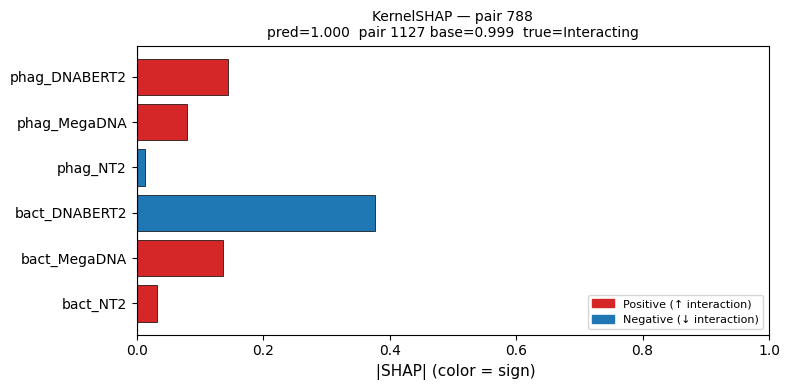

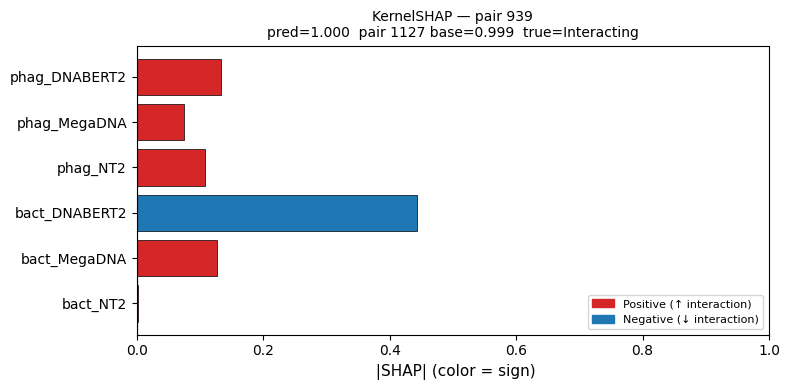

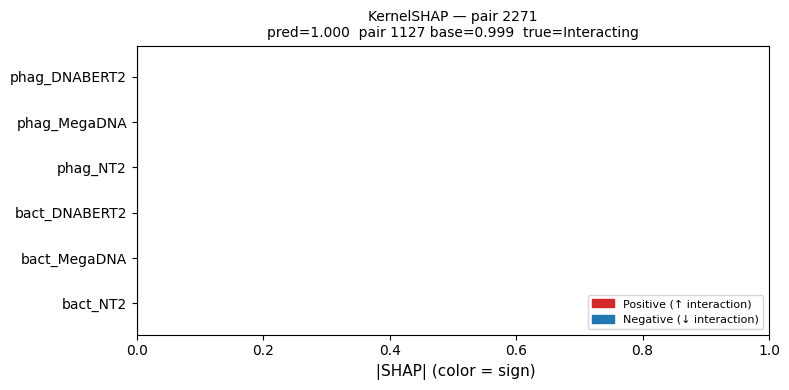

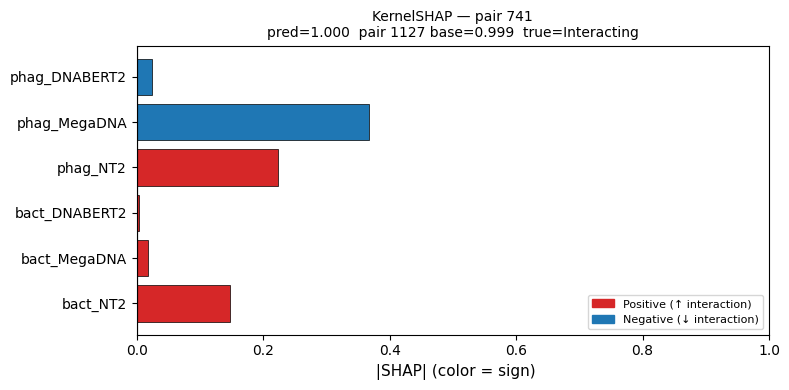

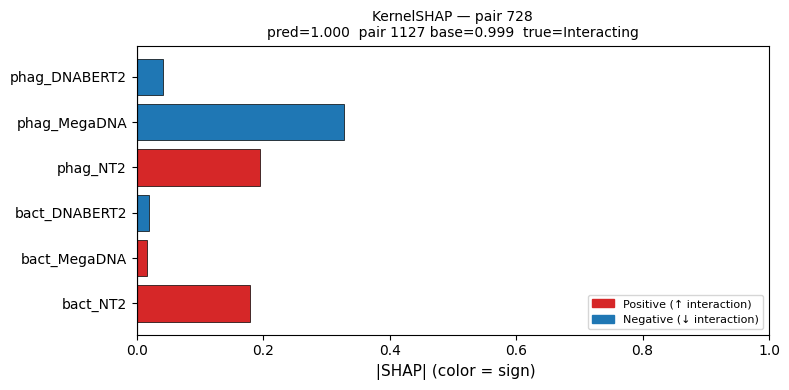

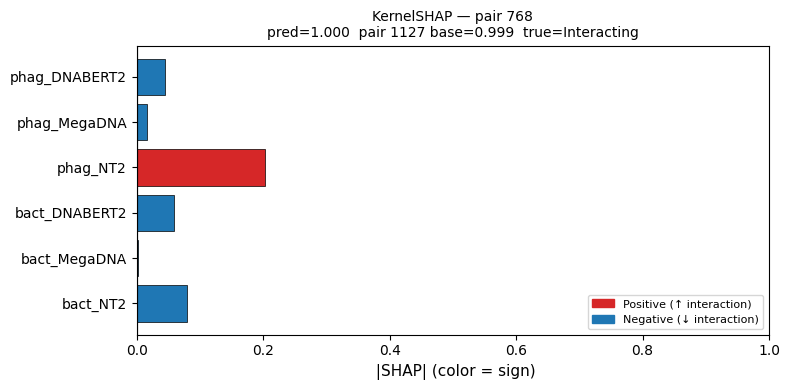

In [ ]:
# ── 11a. Per-pair signed SHAP bar chart ────────────────────────────────────
os.makedirs("XAI/results", exist_ok=True)

for _, row in df_target.iterrows():
    pair_id = int(row["pair_id"])
    vals    = [row[name] for name in BLOCK_NAMES]
    
    # Colors still depend on sign of the original values
    colors  = signed_colors(vals)   # unchanged
    
    base    = float(explainer.expected_value)
    pred    = row["pred_prob"]
    label   = "Interacting" if row["true_label"] == 1 else "Non-interacting"

    fig, ax = plt.subplots(figsize=(8, 4))
    
    # <- key change: use absolute values for bar lengths
    abs_vals = [abs(v) for v in vals]
    ax.barh(BLOCK_NAMES, abs_vals, color=colors, edgecolor="k", linewidth=0.5)
    
    ax.set_xlim(0, 1.0)

    # Optional: remove the zero line or move it to the left edge
    ax.axvline(0, color="k", linewidth=0.8)
    ax.set_xlabel("Mean ablation via SHAP library (color = sign)", fontsize=11)
    ax.set_title(
        f"KernelSHAP — pair {pair_id}\n"
        f"pred={pred:.3f}  {BASELINE_MODE} base={base:.3f}  true={label}",
        fontsize=10,
    )

    pos_patch = mpatches.Patch(color=COLOR_POS, label="Positive (↑ interaction)")
    neg_patch = mpatches.Patch(color=COLOR_NEG, label="Negative (↓ interaction)")
    ax.legend(handles=[pos_patch, neg_patch], fontsize=8, loc="lower right")

    plt.tight_layout()
    fig.savefig(f"XAI/results/{pair_id}_{BASELINE_MODE}_shap_pair.png", dpi=130)
    plt.show()
    plt.close(fig)

## Frozen local explanations

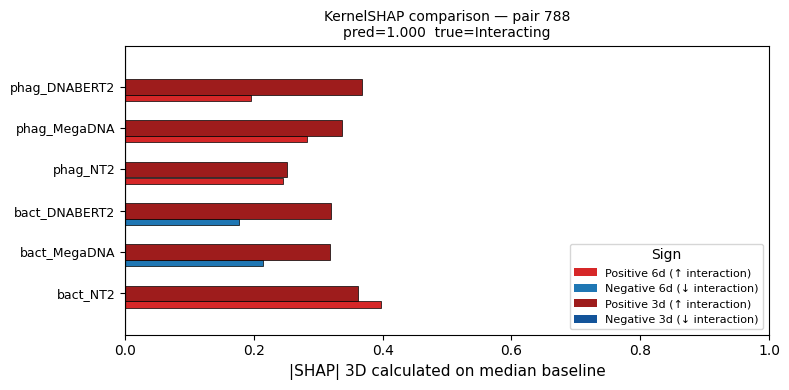

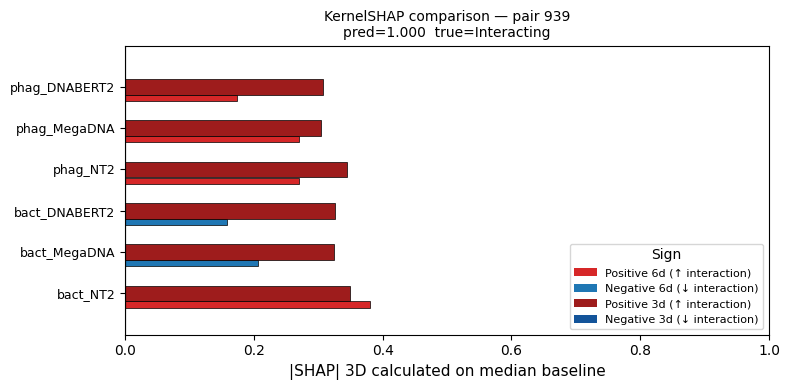

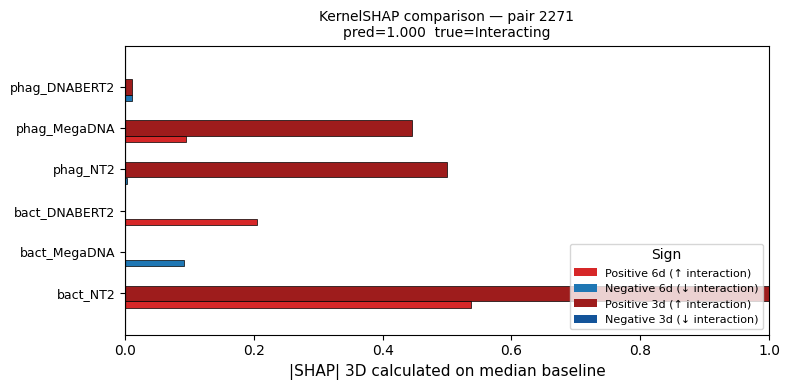

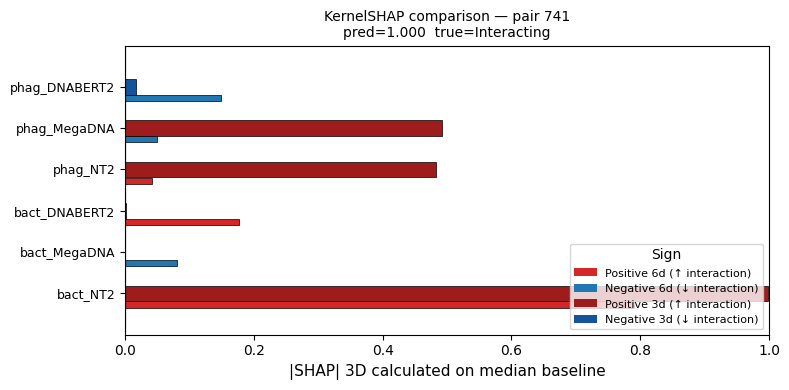

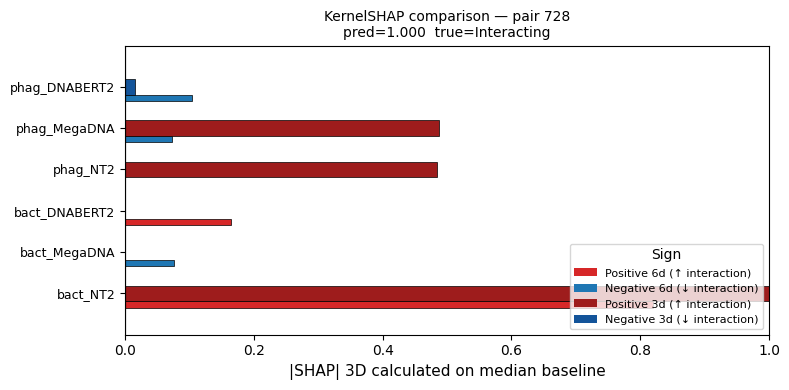

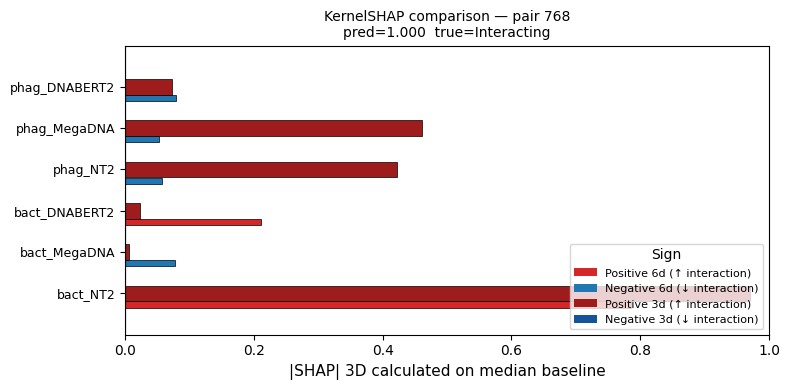

In [ ]:
# ── 11c. Comparison reformatted like 11a (aligned, no weird gaps) ──────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs("XAI/results", exist_ok=True)

COLOR_POS_6D = COLOR_POS   # red
COLOR_NEG_6D = COLOR_NEG   # blue

COLOR_POS_3D = "#9e1c1c"   # dark red
COLOR_NEG_3D = "#13549a"   # dark blue


def signed_color_array(values, pos_color, neg_color):
    return [pos_color if v >= 0 else neg_color for v in values]


for pair in TARGET_PAIRS:
    pid = pair["id"]

    full_6d = df_target.loc[df_target["pair_id"] == pid]
    row_fb  = df_frozen_bact.loc[df_frozen_bact["pair_id"] == pid]
    row_fp  = df_frozen_phag.loc[df_frozen_phag["pair_id"] == pid]

    if full_6d.empty or row_fb.empty or row_fp.empty:
        print(f"  Skipping pair {pid} — missing data in one variant.")
        continue

    full_6d = full_6d.iloc[0]
    row_fb  = row_fb.iloc[0]
    row_fp  = row_fp.iloc[0]

    # 6 blocks in fixed order
    vals_global = np.array([full_6d[n] for n in BLOCK_NAMES], dtype=float)

    vals_fb = np.zeros(6, dtype=float)
    for j, n in enumerate(["phag_NT2", "phag_MegaDNA", "phag_DNABERT2"]):
        vals_fb[3 + j] = row_fb[n]

    vals_fp = np.zeros(6, dtype=float)
    for j, n in enumerate(["bact_NT2", "bact_MegaDNA", "bact_DNABERT2"]):
        vals_fp[j] = row_fp[n]

    abs_global = np.abs(vals_global)
    abs_fb     = np.abs(vals_fb)
    abs_fp     = np.abs(vals_fp)

    # print(f'abs_global = {abs_global}\nabs_fb     = {abs_fb}\nabs_fp     = {abs_fp}\n')

    colors_global = signed_color_array(vals_global, COLOR_POS_6D, COLOR_NEG_6D)
    colors_frozen_b = signed_color_array(vals_fb,     COLOR_POS_3D, COLOR_NEG_3D)
    colors_frozen_p = signed_color_array(vals_fp,     COLOR_POS_3D, COLOR_NEG_3D)

    # One y-position per BLOCK_NAME, evenly spaced
    y = np.arange(len(BLOCK_NAMES), dtype=float)

    # Bar height for each of the 3 bars.
    # Choose a value < 1/3 so that 3 bars fit cleanly with tiny internal gaps.
    bar_height = 0.15
    offset = bar_height  # half-spacing between neighbouring bars

    fig, ax = plt.subplots(figsize=(8, 4))

    # For each block: 3 bars around the central y[i]
    # global (6D) at y[i] - offset, bact-freeze at y[i], phage-freeze at y[i] + offset
    ax.barh(y - offset*1.8, abs_global,
            height=bar_height, color=colors_global,
            edgecolor="k", linewidth=0.5, label="6-dim global")

    ax.barh(y, abs_fb,
            height=bar_height*2.5, color=colors_frozen_b,
            edgecolor="k", linewidth=0.5, label="frozen-bact (3D)")

    ax.barh(y, abs_fp,
            height=bar_height*2.5, color=colors_frozen_p,
            edgecolor="k", linewidth=0.5, label="frozen-phage (3D)")

    # Labels exactly at the central positions y
    ax.set_yticks(y)
    ax.set_yticklabels(BLOCK_NAMES, fontsize=9)

    # Y-limits so the top/bottom bars are fully visible, but spacing is uniform
    ax.set_ylim(-1, len(BLOCK_NAMES))

    #ax.invert_yaxis()
    ax.set_xlim(0, 1.0)
    ax.axvline(0, color="k", linewidth=0.8)

    ax.set_xlabel(f"Mean ablation in 3d space calculated on {BASELINE_MODE} baseline", fontsize=11)
    ax.set_title(
        f"KernelSHAP comparison — pair {pid}\n"
        f"pred={full_6d['pred_prob']:.3f}  true="
        f"{'Interacting' if full_6d['true_label'] == 1 else 'Non-interacting'}",
        fontsize=10,
    )

    sign_handles = [
        mpatches.Patch(facecolor=COLOR_POS_6D, label="Positive 6d (↑ interaction)"),
        mpatches.Patch(facecolor=COLOR_NEG_6D, label="Negative 6d (↓ interaction)"),
        mpatches.Patch(facecolor=COLOR_POS_3D, label="Positive 3d (↑ interaction)"),
        mpatches.Patch(facecolor=COLOR_NEG_3D, label="Negative 3d (↓ interaction)"),

    ]
    ax.legend(handles=sign_handles, fontsize=8, loc="lower right", title="Sign")

    plt.tight_layout()
    fig.savefig(f"XAI/results/{pid}_{BASELINE_MODE}_shap_frosen_pair.png", dpi=130)
    plt.show()
    plt.close(fig)

## Global explanations

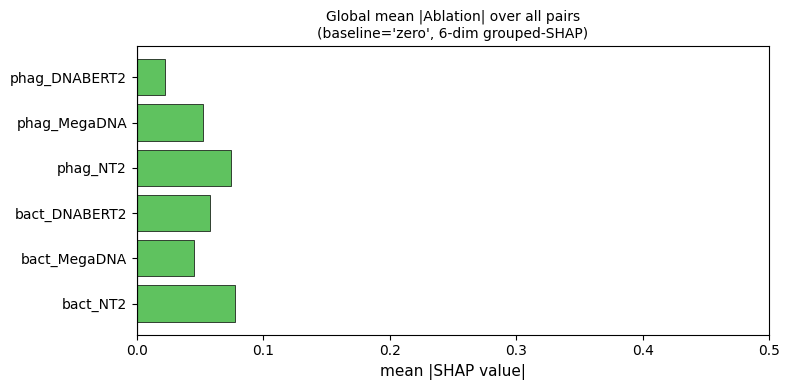

Saved global mean |SHAP| chart.


In [45]:
# ── 11b. Global mean |SHAP| bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

#mean_abs_shap_sorted = mean_abs_shap.sort_index()  # alphabetical by name

# ---------- quick fix ---------------
block_names = list(BLOCKS.keys())

mean_abs_shap = (
    df_global[block_names]
    .abs()
    .mean()
)
# ---------- quick fix ---------------

ax.barh(
    mean_abs_shap.index,
    mean_abs_shap.values,
    color=COLOR_GLOBAL,
    edgecolor="k",
    linewidth=0.5,
)

# Use the same x-axis scale as per-pair charts
ax.set_xlim(0, 0.5)

ax.set_xlabel("mean |SHAP value|", fontsize=11)
ax.set_title(
    f"Global mean |Ablation| over {N_PAIRS_GLOBAL} pairs\n"
    f"(baseline={BASELINE_MODE!r}, 6-dim grouped-SHAP)",
    fontsize=10,
)

# With all positive bars, a vertical line at 0 is optional, but harmless
ax.axvline(0, color="k", linewidth=0.8)

plt.tight_layout()
fig.savefig(f"XAI/results/pictures/global_{BASELINE_MODE}_mean_ablation.png", dpi=130)
plt.show()
plt.close(fig)

print("Saved global mean |SHAP| chart.")

## Global absolut confusion matrix

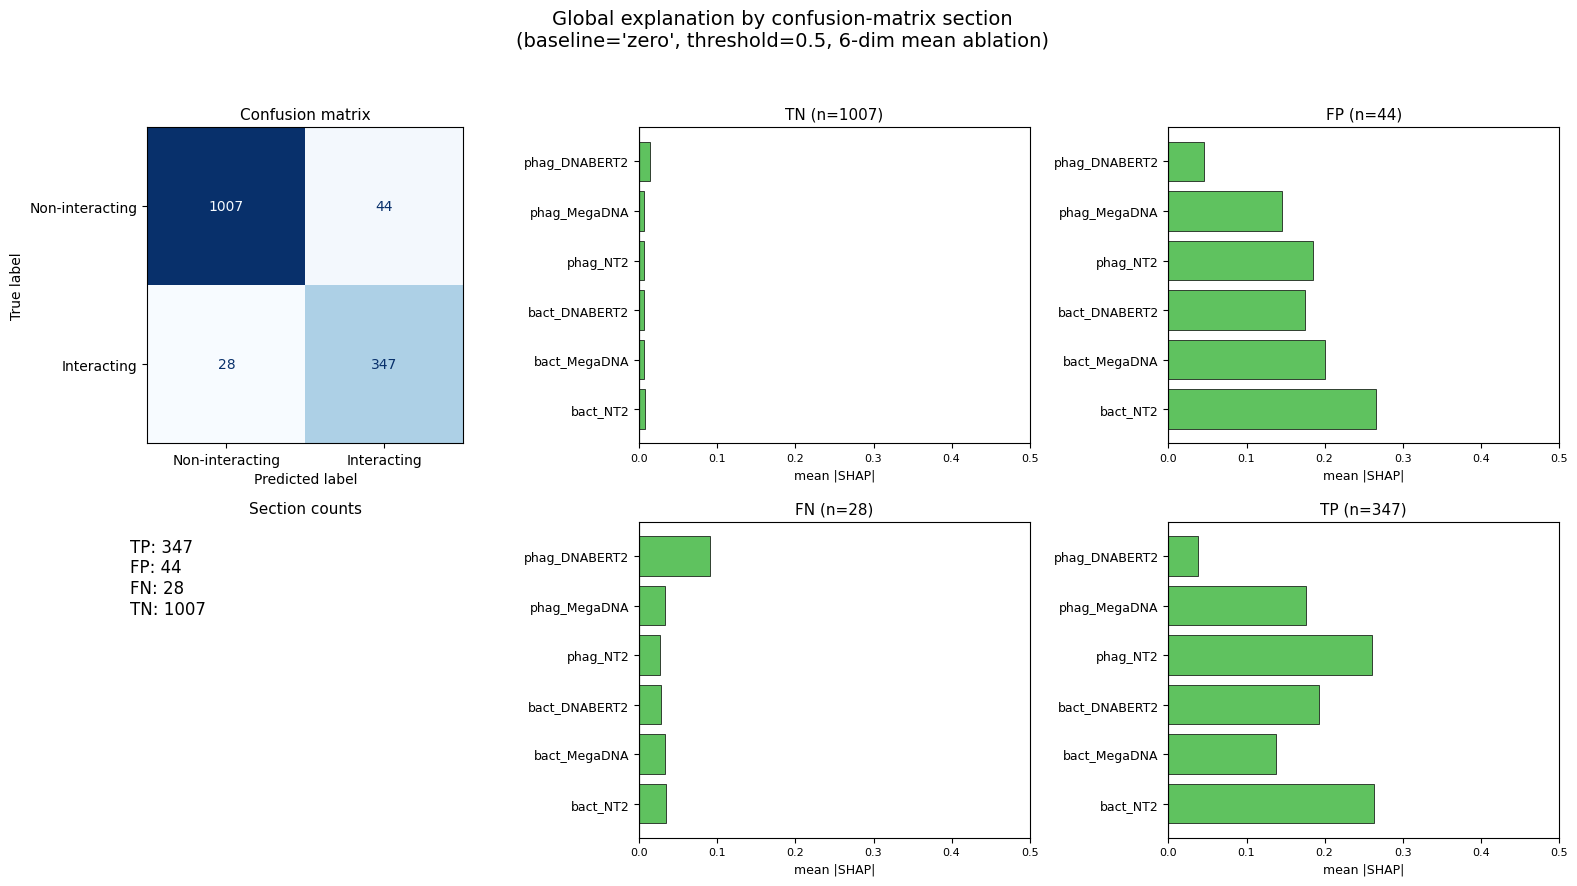

Saved combined confusion-matrix layout.


In [43]:
# ── 11c+. Confusion matrix + SHAP plots in one matrix-like layout ───────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("XAI/results", exist_ok=True)

CLASSIF_THRESHOLD = 0.5

df_cm = df_global.copy()
df_cm["pred_label"] = (df_cm["pred_prob"] >= CLASSIF_THRESHOLD).astype(int)

def cm_section(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 0 and y_pred == 0:
        return "TN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    else:
        raise ValueError("Unexpected label combination.")

df_cm["cm_section"] = [
    cm_section(yt, yp) for yt, yp in zip(df_cm["true_label"], df_cm["pred_label"])
]

# confusion matrix values
cm = confusion_matrix(
    df_cm["true_label"],
    df_cm["pred_label"],
    labels=[0, 1]
)

# ---- ONE FIGURE, MULTIPLE SUBPLOTS ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f"Global explanation by confusion-matrix section\n"
    f"(baseline={BASELINE_MODE!r}, threshold={CLASSIF_THRESHOLD}, 6-dim mean ablation)",
    fontsize=14,
)

# -------------------------------------------------------------------------
# [0,0] confusion matrix
ax_cm = axes[0, 0]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-interacting", "Interacting"]
)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title("Confusion matrix", fontsize=11)

# -------------------------------------------------------------------------
# helper to draw one SHAP chart inside a chosen axis
def plot_section_shap(ax, section_name):
    df_section = df_cm[df_cm["cm_section"] == section_name].copy()
    n_section = len(df_section)

    if n_section == 0:
        ax.text(
            0.5, 0.5,
            f"{section_name}\nno pairs",
            ha="center", va="center",
            fontsize=12,
            transform=ax.transAxes
        )
        ax.set_axis_off()
        return

    mean_abs_shap_section = (
        df_section[BLOCK_NAMES]
        .abs()
        .mean()
    )

    ax.barh(
        mean_abs_shap_section.index,
        mean_abs_shap_section.values,
        color=COLOR_GLOBAL,
        edgecolor="k",
        linewidth=0.5,
    )
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("mean |SHAP|", fontsize=9)
    ax.set_title(f"{section_name} (n={n_section})", fontsize=11)
    ax.axvline(0, color="k", linewidth=0.8)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)

# -------------------------------------------------------------------------
# Put the SHAP plots around the matrix
plot_section_shap(axes[1, 2], "TP")
plot_section_shap(axes[0, 2], "FP")
plot_section_shap(axes[1, 1], "FN")
plot_section_shap(axes[0, 1], "TN")

# optional panel: counts summary
axes[1, 0].axis("off")
section_counts = df_cm["cm_section"].value_counts()
summary_text = "\n".join([
    f"TP: {section_counts.get('TP', 0)}",
    f"FP: {section_counts.get('FP', 0)}",
    f"FN: {section_counts.get('FN', 0)}",
    f"TN: {section_counts.get('TN', 0)}",
])
axes[1, 0].text(
    0.05, 0.95,
    summary_text,
    ha="left", va="top",
    fontsize=12,
    transform=axes[1, 0].transAxes
)
axes[1, 0].set_title("Section counts", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f"XAI/results/pictures/confusion_matrix_with_abs_ablation_on_{BASELINE_MODE}.png", dpi=150)
plt.show()
plt.close(fig)

print("Saved combined confusion-matrix layout.")

## Global mean/medan contribution matrix

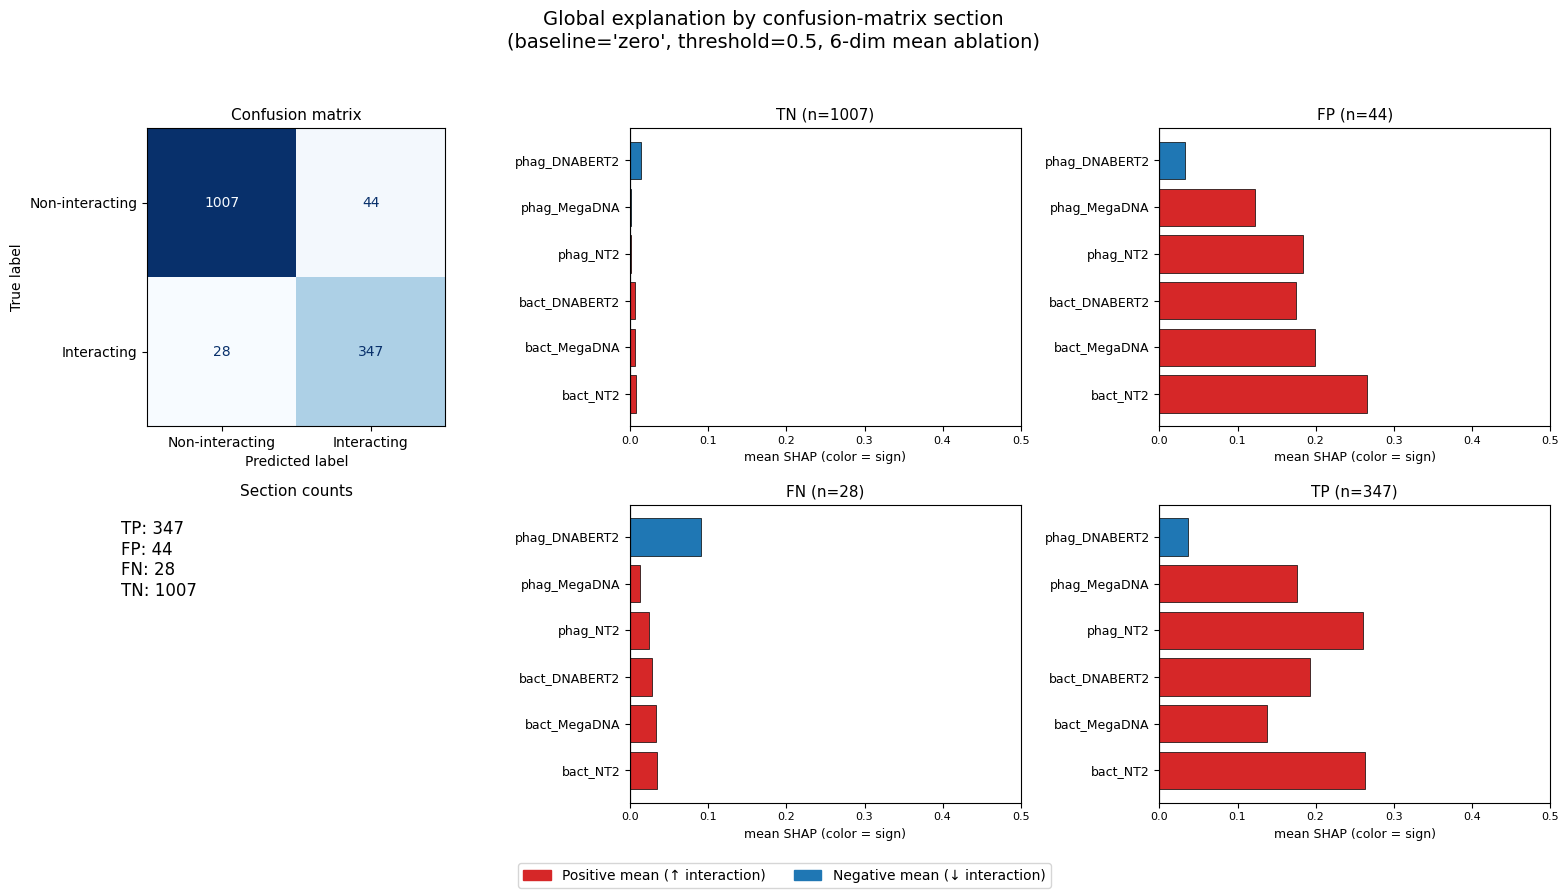

Saved combined confusion-matrix layout.


In [44]:
# ── 11c+++. Confusion matrix + SHAP plots in one matrix-like layout ───────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs("XAI/results", exist_ok=True)

CLASSIF_THRESHOLD = 0.5

df_cm = df_global.copy()
df_cm["pred_label"] = (df_cm["pred_prob"] >= CLASSIF_THRESHOLD).astype(int)

def cm_section(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 0 and y_pred == 0:
        return "TN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    else:
        raise ValueError("Unexpected label combination.")

df_cm["cm_section"] = [
    cm_section(yt, yp) for yt, yp in zip(df_cm["true_label"], df_cm["pred_label"])
]

# confusion matrix values
cm = confusion_matrix(
    df_cm["true_label"],
    df_cm["pred_label"],
    labels=[0, 1]
)

# ---- ONE FIGURE, MULTIPLE SUBPLOTS ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f"Global explanation by confusion-matrix section\n"
    f"(baseline={BASELINE_MODE!r}, threshold={CLASSIF_THRESHOLD}, 6-dim mean ablation)",
    fontsize=14,
)

# -------------------------------------------------------------------------
# [0,0] confusion matrix
ax_cm = axes[0, 0]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-interacting", "Interacting"]
)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title("Confusion matrix", fontsize=11)

# -------------------------------------------------------------------------
# helper to draw one SHAP chart inside a chosen axis
def plot_section_shap(ax, section_name):
    df_section = df_cm[df_cm["cm_section"] == section_name].copy()
    n_section = len(df_section)

    if n_section == 0:
        ax.text(
            0.5, 0.5,
            f"{section_name}\nno pairs",
            ha="center", va="center",
            fontsize=12,
            transform=ax.transAxes
        )
        ax.set_axis_off()
        return

    # signed mean SHAP, not absolute mean
    mean_shap_section = (
        df_section[BLOCK_NAMES]
        .mean()
    )

    # bar length goes right, color keeps the sign information
    abs_mean_vals = mean_shap_section.abs().values
    colors = signed_colors(mean_shap_section.values)

    ax.barh(
        mean_shap_section.index,
        abs_mean_vals,
        color=colors,
        edgecolor="k",
        linewidth=0.5,
    )

    ax.set_xlim(0, 0.5)
    ax.set_xlabel("mean SHAP (color = sign)", fontsize=9)
    ax.set_title(f"{section_name} (n={n_section})", fontsize=11)
    ax.axvline(0, color="k", linewidth=0.8)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)

    # optional: alphabetical top-to-bottom instead of bottom-to-top
    #ax.invert_yaxis()

# -------------------------------------------------------------------------
# Put the SHAP plots around the matrix
plot_section_shap(axes[1, 2], "TP")
plot_section_shap(axes[0, 2], "FP")
plot_section_shap(axes[1, 1], "FN")
plot_section_shap(axes[0, 1], "TN")

# optional panel: counts summary
axes[1, 0].axis("off")
section_counts = df_cm["cm_section"].value_counts()
summary_text = "\n".join([
    f"TP: {section_counts.get('TP', 0)}",
    f"FP: {section_counts.get('FP', 0)}",
    f"FN: {section_counts.get('FN', 0)}",
    f"TN: {section_counts.get('TN', 0)}",
])
axes[1, 0].text(
    0.05, 0.95,
    summary_text,
    ha="left", va="top",
    fontsize=12,
    transform=axes[1, 0].transAxes
)
axes[1, 0].set_title("Section counts", fontsize=11)

# optional shared legend
pos_patch = mpatches.Patch(color=COLOR_POS, label="Positive mean (↑ interaction)")
neg_patch = mpatches.Patch(color=COLOR_NEG, label="Negative mean (↓ interaction)")
fig.legend(handles=[pos_patch, neg_patch], loc="lower center", ncol=2, fontsize=10)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(f"XAI/results/pictures/confusion_matrix_with_mean_ablation_on_{BASELINE_MODE}.png", dpi=150)
plt.show()
plt.close(fig)

print("Saved combined confusion-matrix layout.")

___
## Saving The Results

In [30]:
''' Json

os.makedirs("XAI/results/data", exist_ok=True)

# ── 6-dim global results ───────────────────────────────────────────────────
out_path_global = f"XAI/results/data/nb1_kernel_{BASELINE_MODE}.json"
with open(out_path_global, "w") as f:
    json.dump(json_results, f, indent=2)
print(f"Saved {len(json_results)} global results → {out_path_global}")

# ── Frozen-bacteria results ────────────────────────────────────────────────
out_path_fb = f"XAI/results/data/nb1_kernel_{BASELINE_MODE}_frozen_bact.json"
with open(out_path_fb, "w") as f:
    json.dump(json_frozen_bact, f, indent=2)
print(f"Saved {len(json_frozen_bact)} frozen-bact results → {out_path_fb}")

# ── Frozen-phage results ───────────────────────────────────────────────────
out_path_fp = f"XAI/results/data/nb1_kernel_{BASELINE_MODE}_frozen_phag.json"
with open(out_path_fp, "w") as f:
    json.dump(json_frozen_phag, f, indent=2)
print(f"Saved {len(json_frozen_phag)} frozen-phage results → {out_path_fp}")
'''

' Json\n\nos.makedirs("XAI/results/data", exist_ok=True)\n\n# ── 6-dim global results ───────────────────────────────────────────────────\nout_path_global = f"XAI/results/data/nb1_kernel_{BASELINE_MODE}.json"\nwith open(out_path_global, "w") as f:\n    json.dump(json_results, f, indent=2)\nprint(f"Saved {len(json_results)} global results → {out_path_global}")\n\n# ── Frozen-bacteria results ────────────────────────────────────────────────\nout_path_fb = f"XAI/results/data/nb1_kernel_{BASELINE_MODE}_frozen_bact.json"\nwith open(out_path_fb, "w") as f:\n    json.dump(json_frozen_bact, f, indent=2)\nprint(f"Saved {len(json_frozen_bact)} frozen-bact results → {out_path_fb}")\n\n# ── Frozen-phage results ───────────────────────────────────────────────────\nout_path_fp = f"XAI/results/data/nb1_kernel_{BASELINE_MODE}_frozen_phag.json"\nwith open(out_path_fp, "w") as f:\n    json.dump(json_frozen_phag, f, indent=2)\nprint(f"Saved {len(json_frozen_phag)} frozen-phage results → {out_path_fp}")\n

In [31]:
import os

os.makedirs("XAI/results/data", exist_ok=True)

# ── 1. Full global dump as its own file ─────────────────────────────────────
out_global_csv = f"XAI/results/data/nb1_{BASELINE_MODE}_global_on_{N_PAIRS_GLOBAL}_pairs.csv"
df_global.to_csv(out_global_csv, index=False)
print(f"Saved global dump CSV → {out_global_csv}")

# ── 2. Combine target with frozen-only results ──────────────────────────────
df_target_frozen = (
    df_target
    .merge(
        df_frozen_bact,
        on=["pair_id", "bacterium_id", "phage_id", "true_label"],
        how="left",
        suffixes=("", "_fb")
    )
    .merge(
        df_frozen_phag,
        on=["pair_id", "bacterium_id", "phage_id", "true_label"],
        how="left",
        suffixes=("", "_fp")
    )
)

df_target_frozen = df_target_frozen.drop(
    columns=[
        "pred_prob_fb",
        "pred_prob_fp",
        "frozen_side",
        "frozen_side_fp",
    ])

out_target_frozen_csv = f"XAI/results/data/nb1_{BASELINE_MODE}_target.csv"
df_target_frozen.to_csv(out_target_frozen_csv, index=False)
print(f"Saved target+frozen CSV → {out_target_frozen_csv}")

Saved global dump CSV → XAI/results/data/nb1_median_global_on_all_pairs.csv
Saved target+frozen CSV → XAI/results/data/nb1_median_target.csv


In [32]:
# ── Final summary ──────────────────────────────────────────────────────────
print("=" * 60)
print("NB1 KernelSHAP run complete.")
print(f"  Baseline mode      : {BASELINE_MODE}")
print(f"  Target pairs       : {len(TARGET_PAIRS)}")
print(f"  Global pairs       : {N_PAIRS_GLOBAL}")
print(f"  Outputs in         : XAI/results/")
print("=" * 60)
print("\nGlobal mean |SHAP| ranking:")
for rank, (block, val) in enumerate(mean_abs_shap.items(), 1):
    print(f"  {rank}. {block:<20} {val:.5f}")

NB1 KernelSHAP run complete.
  Baseline mode      : median
  Target pairs       : 6
  Global pairs       : all
  Outputs in         : XAI/results/

Global mean |SHAP| ranking:
  1. bact_NT2             0.28317
  2. bact_MegaDNA         0.11710
  3. bact_DNABERT2        0.13493
  4. phag_NT2             0.18002
  5. phag_MegaDNA         0.12367
  6. phag_DNABERT2        0.09609
